In [2]:
import opendatasets as od
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, ConcatDataset, random_split
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torchvision import models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve
from PIL import Image

In [4]:
# Проверка доступности GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device # Если cpu, то смерть

device(type='cuda')

In [5]:
# Загрузка датасета
dataset_url = 'https://www.kaggle.com/datasets/sanikamal/horses-or-humans-dataset'
od.download(dataset_url)

In [6]:
data_dir = 'horses-or-humans-dataset/horse-or-human'
train_dir = os.path.join(data_dir, 'train')
validation_dir = os.path.join(data_dir, 'validation')

In [7]:
IMG_SIZE = 150

# Аугментация
augmentation_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor()
])

base_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

In [ ]:
# Загрузка
train_dataset = datasets.ImageFolder(root=train_dir, transform=base_transforms)
val_dataset = datasets.ImageFolder(root=validation_dir, transform=base_transforms)

all_data = ConcatDataset([train_dataset, val_dataset])

test_size = int(0.2 * len(all_data))
train_size = len(all_data) - test_size

train_dataset, test_dataset = random_split(all_data, [train_size, test_size])

In [9]:
base_dataset = datasets.ImageFolder(root=train_dir, transform=base_transforms)
augmented_datasets = [base_dataset]  # начинаем с оригинального набора

for _ in range(3):
  aug_dataset = datasets.ImageFolder(root=train_dir, transform=augmentation_transforms)
  augmented_datasets.append(aug_dataset)

# Объединяем все наборы
train_dataset = ConcatDataset(augmented_datasets)

In [10]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    num_workers=2
)

class_names = base_dataset.classes

In [11]:
len(train_dataset), len(test_dataset)

(4108, 256)

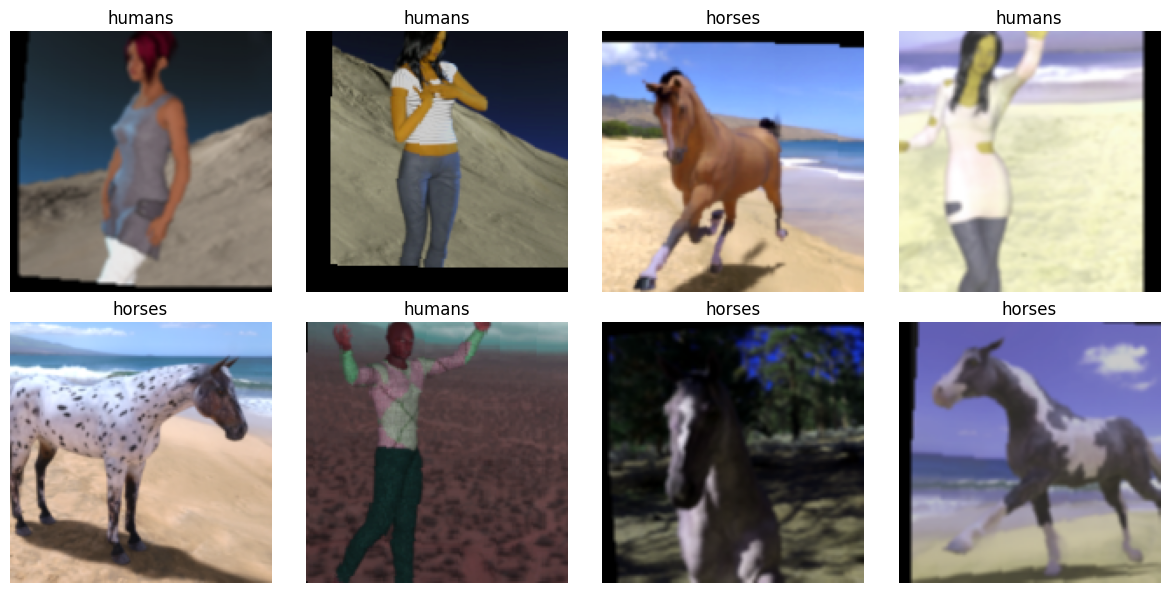

In [12]:
def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.axis('off')

# Получаем батч данных
images, labels = next(iter(train_loader))

# Визуализируем
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.ravel()

for i in range(8):
    axes[i].imshow(images[i].numpy().transpose((1, 2, 0)))
    axes[i].set_title(class_names[labels[i]])
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 18 * 18, 64),
            nn.ReLU(),
            nn.Dropout(0.6), # От переобучения
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [ ]:
model = CNN().to(device)
criterion = nn.BCELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01) # + регуляризация
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

In [ ]:
# Функции для обучения
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (data, target) in enumerate(dataloader):
        data, target = data.to(device), target.to(device).float().unsqueeze(1)

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        predicted = (output > 0.5).float()
        total += target.size(0)
        correct += (predicted == target).sum().item()

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [ ]:
def validate_epoch(model, dataloader, criterion, device): # Считаем метрики
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_probs = []
    all_targets = []

    with torch.no_grad():
        for data, target in dataloader:
            data, target = data.to(device), target.to(device).float().unsqueeze(1)

            output = model(data)
            loss = criterion(output, target)

            running_loss += loss.item()
            predicted = (output > 0.5).float()
            total += target.size(0)
            correct += (predicted == target).sum().item()

            all_probs.extend(output.cpu().numpy())
            all_targets.extend(target.cpu().numpy())

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = correct / total

    # Вычисляем ROC-AUC
    auc_score = roc_auc_score(all_targets, all_probs)

    return epoch_loss, epoch_acc, auc_score, all_probs, all_targets

In [17]:
# Обучение модели
num_epochs = 5
train_losses = []
val_losses = []
train_accs = []
val_accs = []
auc_scores = []

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, auc_score, _, _ = validate_epoch(model, test_loader, criterion, device)

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    auc_scores.append(auc_score)

    print(f'Epoch {epoch+1}/{num_epochs}:')
    print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')
    print(f'  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')
    print(f'  ROC-AUC: {auc_score:.4f}')
    print('=' * 50)

Epoch 1/5:
  Train Loss: 0.4285, Train Acc: 0.8194
  Val Loss: 0.1900, Val Acc: 0.9297
  ROC-AUC: 0.9743
Epoch 2/5:
  Train Loss: 0.1961, Train Acc: 0.9094
  Val Loss: 0.7320, Val Acc: 0.9375
  ROC-AUC: 0.9784
Epoch 3/5:
  Train Loss: 0.1528, Train Acc: 0.9370
  Val Loss: 0.2280, Val Acc: 0.9766
  ROC-AUC: 0.9796
Epoch 4/5:
  Train Loss: 0.1503, Train Acc: 0.9421
  Val Loss: 0.6836, Val Acc: 0.9531
  ROC-AUC: 0.9825
Epoch 5/5:
  Train Loss: 0.1405, Train Acc: 0.9426
  Val Loss: 1.4326, Val Acc: 0.9375
  ROC-AUC: 0.9809


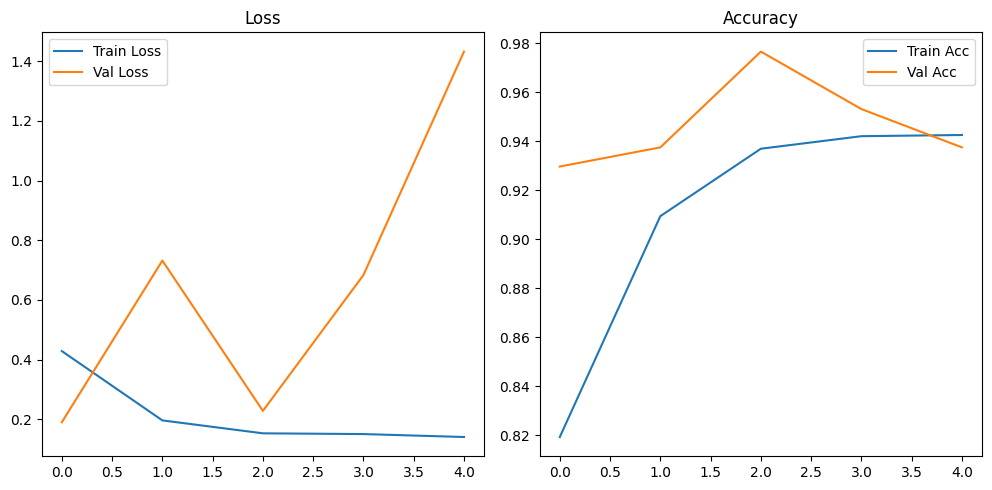

In [18]:
# Визуализация результатов обучения
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

**От переобучения не спаслись**

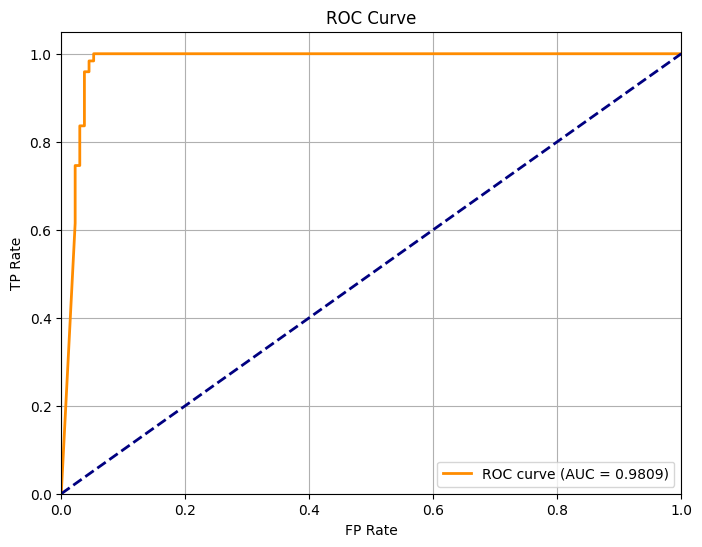

In [19]:
# Финальная оценка
final_val_loss, final_val_acc, final_auc, all_probs, all_targets = validate_epoch(model, test_loader, criterion, device)

# ROC-кривая
fpr, tpr, thresholds = roc_curve(all_targets, all_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {final_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('FP Rate')
plt.ylabel('TP Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [20]:
torch.save(model.state_dict(), 'model.pth')